# Tutorial 3: Solutions to Exercises 3.1 & 3.2

![Status](https://img.shields.io/static/v1.svg?label=Status&message=Open&color=blue)


**Open notebook on:** 
[![View filled on Github](https://img.shields.io/static/v1.svg?logo=github&label=Repo&message=View%20On%20Github&color=lightgrey)](https://github.com/clandolt/mlcysec_notebooks/blob/main/source/tutorial_notebooks/tutorial3_solution/tutorial3_solution.ipynb)
[![Open filled In Collab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/clandolt/mlcysec_notebooks/blob/main/source/tutorial_notebooks/tutorial3_solution/tutorial3_solution.ipynb)   
**Author:** Christoph R. Landolt

This notebook provides the solutions for the exercises corresponding to Tutorials 3.1 and 3.2.

## Solutions for Tutorial 3.1: Getting started with GANs

### Exercise 1: Experimenting with Architectural Changes

#### 1. Implementation: High-Capacity Generator
In this exercise, we investigate how increasing the capacity (the number of layers and neurons) of the Generator affects the training outcome when the Discriminator remains simple.

We modified the `Generator` class to include an additional hidden layer and increased the width of the layers from 50 to 128 neurons.

**Original Generator:**
```python
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        # Input dimension is 10 (noise), output dimension is 2 (for 2D data)
        self.fc = nn.Sequential(
            nn.Linear(10, 50),
            nn.ReLU(),
            nn.Linear(50, 2)
        )
```
**High-Capacity Generator:**
```python
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        # Input dimension is 10 (noise), output dimension is 2 (for 2D data)
        self.fc = nn.Sequential(
            nn.Linear(10, 50),
            nn.ReLU(),
            nn.Linear(50, 2)
        )
```


Training with High-Capacity Generator on cpu...
Epoch [0/10000] | Loss D: 2.3853 | Loss G: 0.6585
Epoch [1000/10000] | Loss D: 1.4730 | Loss G: 0.6600
Epoch [2000/10000] | Loss D: 1.2944 | Loss G: 0.7798
Epoch [3000/10000] | Loss D: 1.7352 | Loss G: 0.5906
Epoch [4000/10000] | Loss D: 1.2874 | Loss G: 0.7426
Epoch [5000/10000] | Loss D: 1.4147 | Loss G: 0.6181
Epoch [6000/10000] | Loss D: 1.4654 | Loss G: 0.6584
Epoch [7000/10000] | Loss D: 1.3330 | Loss G: 0.9366
Epoch [8000/10000] | Loss D: 1.4036 | Loss G: 0.7082
Epoch [9000/10000] | Loss D: 1.3616 | Loss G: 0.6705


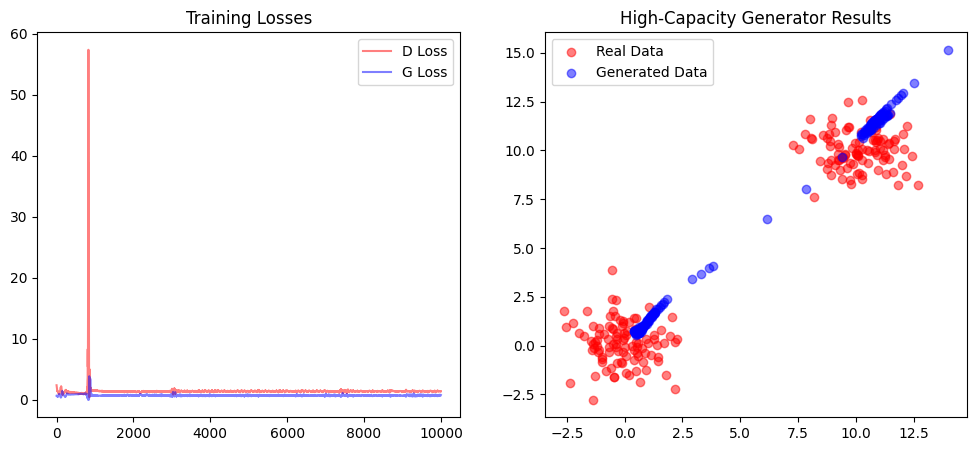

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 1. Define the Models ---

class HighCapacityGenerator(nn.Module):
    def __init__(self, input_dim=10, output_dim=2):
        super(HighCapacityGenerator, self).__init__()
        # Enhanced architecture: Adding an extra hidden layer and increasing width
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim)
        )

    def forward(self, x):
        return self.fc(x)

class Discriminator(nn.Module):
    def __init__(self, input_dim=2):
        super(Discriminator, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 50),
            nn.ReLU(),
            nn.Linear(50, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.fc(x)

# --- 2. Utility Functions ---

def generate_real_data(batch_size=64, mean1=0.0, mean2=10.0, std=1.0):
    half_batch = batch_size // 2
    data1 = np.random.normal(mean1, std, (half_batch, 2))
    data2 = np.random.normal(mean2, std, (batch_size - half_batch, 2))
    combined_data = np.vstack([data1, data2])
    return torch.tensor(combined_data, dtype=torch.float32).to(device)

def generate_noise(batch_size=64, noise_dim=10):
    return torch.randn(batch_size, noise_dim).to(device)

# --- 3. Initialization ---

noise_dim = 10
generator = HighCapacityGenerator(input_dim=noise_dim).to(device)
discriminator = Discriminator().to(device)

criterion = nn.BCELoss()
optimizer_g = optim.Adam(generator.parameters(), lr=0.001)
optimizer_d = optim.Adam(discriminator.parameters(), lr=0.001)

# Training parameters
num_epochs = 10000
batch_size = 64
losses_d = []
losses_g = []

# --- 4. Training Loop ---

print(f"Training with High-Capacity Generator on {device}...")

for epoch in range(num_epochs):
    # --- Step A: Train Discriminator ---
    optimizer_d.zero_grad()
    
    # Real data labels = 1, Fake data labels = 0
    real_data = generate_real_data(batch_size)
    real_labels = torch.ones(batch_size, 1).to(device)
    
    noise = generate_noise(batch_size, noise_dim)
    fake_data = generator(noise).detach() # Detach to avoid updating Generator
    fake_labels = torch.zeros(batch_size, 1).to(device)
    
    # D Loss
    out_real = discriminator(real_data)
    loss_d_real = criterion(out_real, real_labels)
    
    out_fake = discriminator(fake_data)
    loss_d_fake = criterion(out_fake, fake_labels)
    
    loss_d = loss_d_real + loss_d_fake
    loss_d.backward()
    optimizer_d.step()
    
    # --- Step B: Train Generator ---
    optimizer_g.zero_grad()
    
    noise = generate_noise(batch_size, noise_dim)
    fake_data = generator(noise)
    
    # G wants D to think fake data is real (label = 1)
    out_fake_for_g = discriminator(fake_data)
    loss_g = criterion(out_fake_for_g, real_labels)
    
    loss_g.backward()
    optimizer_g.step()
    
    # Save statistics
    losses_d.append(loss_d.item())
    losses_g.append(loss_g.item())

    if epoch % 1000 == 0:
        print(f"Epoch [{epoch}/{num_epochs}] | Loss D: {loss_d.item():.4f} | Loss G: {loss_g.item():.4f}")

# --- 5. Visualization ---

# Plot Losses
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(losses_d, label='D Loss', color='red', alpha=0.5)
plt.plot(losses_g, label='G Loss', color='blue', alpha=0.5)
plt.title("Training Losses")
plt.legend()

# Plot Generated Data vs Real Data
plt.subplot(1, 2, 2)
generator.eval()
with torch.no_grad():
    test_noise = generate_noise(200, noise_dim)
    generated = generator(test_noise).cpu().numpy()
    real = generate_real_data(200).cpu().numpy()

plt.scatter(real[:, 0], real[:, 1], c='red', label='Real Data', alpha=0.5)
plt.scatter(generated[:, 0], generated[:, 1], c='blue', label='Generated Data', alpha=0.5)
plt.title("High-Capacity Generator Results")
plt.legend()
plt.show()

**Analysis of the Results:**

Increasing Generator capacity without a corresponding increase in Discriminator capacity (or better loss functions) does not necessarily improve results. Here, the Generator became powerful enough to exploit the Discriminator's "blind spots" rather than learning the actual data distribution.

#### 2. Implementation: High-Capacity Discriminator

In this step, we investigate the effect of increasing the capacity of the Discriminator to match the complexity of the Generator. By providing the Discriminator with more layers and neurons, we aim to create a more sophisticated "critic" that can theoretically provide a more detailed loss landscape for the Generator to learn from.

We modified the `Discriminator` class to include an additional hidden layer and increased the width of the layers from 50 to 128 neurons.

**Original Discriminator:**
```python
class Discriminator(nn.Module):
    def __init__(self, input_dim=2):
        super(Discriminator, self).__init__()
        # Architecture: 2 -> 50 -> 1
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 50),
            nn.ReLU(),
            nn.Linear(50, 1),
            nn.Sigmoid()
        )

```
**High-Capacity Discriminator:**
```python
class HighCapacityDiscriminator(nn.Module):
    def __init__(self, input_dim=2):
        super(HighCapacityDiscriminator, self).__init__()
        # Architecture: 2 -> 128 -> 128 -> 1
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            # Increased capacity to match the Generator
            nn.Linear(128, 1),
            nn.Sigmoid()
        )
```


Training with High-Capacity Generator AND Discriminator on cpu...
Epoch [0/10000] | Loss D: 1.3395 | Loss G: 0.6741
Epoch [1000/10000] | Loss D: 0.9498 | Loss G: 1.0741
Epoch [2000/10000] | Loss D: 1.8334 | Loss G: 1.0794
Epoch [3000/10000] | Loss D: 1.4157 | Loss G: 0.7272
Epoch [4000/10000] | Loss D: 1.2811 | Loss G: 0.7338
Epoch [5000/10000] | Loss D: 1.2811 | Loss G: 0.8065
Epoch [6000/10000] | Loss D: 1.2619 | Loss G: 0.9606
Epoch [7000/10000] | Loss D: 1.1284 | Loss G: 0.9045
Epoch [8000/10000] | Loss D: 1.2806 | Loss G: 0.8654
Epoch [9000/10000] | Loss D: 1.1076 | Loss G: 0.8248


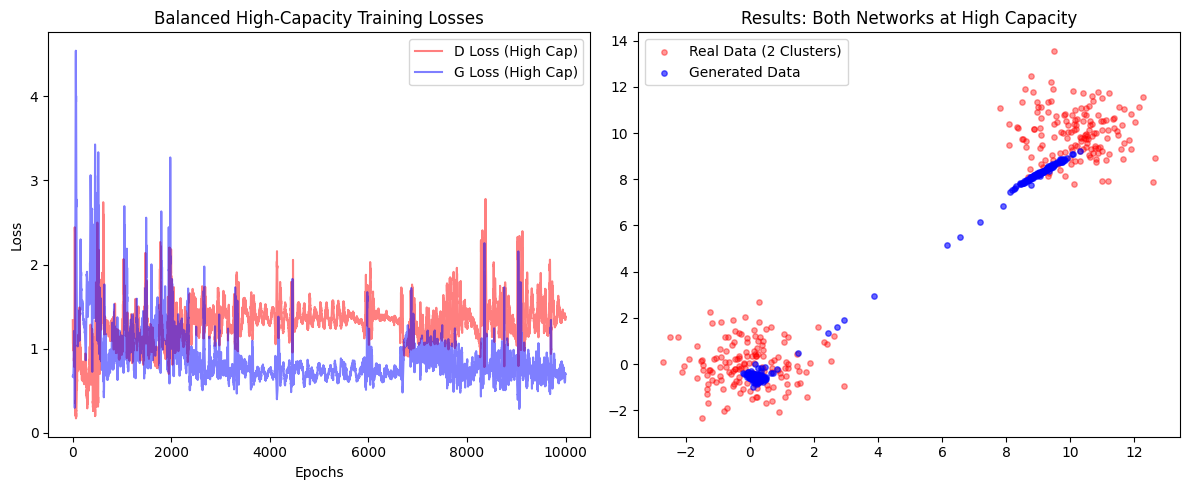

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 1. Define High-Capacity Models ---

class HighCapacityGenerator(nn.Module):
    def __init__(self, input_dim=10, output_dim=2):
        super(HighCapacityGenerator, self).__init__()
        # Architecture: 10 -> 128 -> 128 -> 2
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim)
        )

    def forward(self, x):
        return self.fc(x)

class HighCapacityDiscriminator(nn.Module):
    def __init__(self, input_dim=2):
        super(HighCapacityDiscriminator, self).__init__()
        # Architecture: 2 -> 128 -> 128 -> 1
        # Increased capacity to match the Generator
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.fc(x)

# --- 2. Utility Functions ---

def generate_real_data(batch_size=64, mean1=0.0, mean2=10.0, std=1.0):
    half_batch = batch_size // 2
    data1 = np.random.normal(mean1, std, (half_batch, 2))
    data2 = np.random.normal(mean2, std, (batch_size - half_batch, 2))
    combined_data = np.vstack([data1, data2])
    return torch.tensor(combined_data, dtype=torch.float32).to(device)

def generate_noise(batch_size=64, noise_dim=10):
    return torch.randn(batch_size, noise_dim).to(device)

# --- 3. Initialization ---

noise_dim = 10
generator = HighCapacityGenerator(input_dim=noise_dim).to(device)
discriminator = HighCapacityDiscriminator().to(device)

criterion = nn.BCELoss()
optimizer_g = optim.Adam(generator.parameters(), lr=0.001)
optimizer_d = optim.Adam(discriminator.parameters(), lr=0.001)

# Training parameters
num_epochs = 10000
batch_size = 64
losses_d = []
losses_g = []

# --- 4. Training Loop ---

print(f"Training with High-Capacity Generator AND Discriminator on {device}...")

for epoch in range(num_epochs):
    # --- Step A: Train Discriminator ---
    optimizer_d.zero_grad()
    
    real_data = generate_real_data(batch_size)
    real_labels = torch.ones(batch_size, 1).to(device)
    
    noise = generate_noise(batch_size, noise_dim)
    fake_data = generator(noise).detach() 
    fake_labels = torch.zeros(batch_size, 1).to(device)
    
    # Forward passes
    out_real = discriminator(real_data)
    out_fake = discriminator(fake_data)
    
    loss_d = criterion(out_real, real_labels) + criterion(out_fake, fake_labels)
    loss_d.backward()
    optimizer_d.step()
    
    # --- Step B: Train Generator ---
    optimizer_g.zero_grad()
    
    noise = generate_noise(batch_size, noise_dim)
    fake_data = generator(noise)
    
    # Try to fool the high-capacity discriminator
    out_fake_for_g = discriminator(fake_data)
    loss_g = criterion(out_fake_for_g, real_labels)
    
    loss_g.backward()
    optimizer_g.step()
    
    losses_d.append(loss_d.item())
    losses_g.append(loss_g.item())

    if epoch % 1000 == 0:
        print(f"Epoch [{epoch}/{num_epochs}] | Loss D: {loss_d.item():.4f} | Loss G: {loss_g.item():.4f}")

# --- 5. Visualization ---

plt.figure(figsize=(12, 5))

# Plot Losses
plt.subplot(1, 2, 1)
plt.plot(losses_d, label='D Loss (High Cap)', color='red', alpha=0.5)
plt.plot(losses_g, label='G Loss (High Cap)', color='blue', alpha=0.5)
plt.title("Balanced High-Capacity Training Losses")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

# Plot Results
plt.subplot(1, 2, 2)
generator.eval()
with torch.no_grad():
    test_noise = generate_noise(300, noise_dim)
    generated = generator(test_noise).cpu().numpy()
    real = generate_real_data(300).cpu().numpy()

plt.scatter(real[:, 0], real[:, 1], c='red', label='Real Data (2 Clusters)', alpha=0.4, s=15)
plt.scatter(generated[:, 0], generated[:, 1], c='blue', label='Generated Data', alpha=0.6, s=15)
plt.title("Results: Both Networks at High Capacity")
plt.legend()
plt.tight_layout()
plt.show()

**Analysis of the Results:**

Run the code multiple times and observe that the strategy changes every time; the Generator may focus on the top cluster, the bottom cluster, or a line between them. This occurs because the Generator discovers a small region that fools the Discriminator but fails to capture the true diversity of the data. Raw model power cannot overcome fundamental instabilities like oscillating losses and mode collapse without structural changes.

#### 3. Implementation: Imbalance the Networks
In this final experiment, we explore scenarios where one player in the adversarial game is significantly more powerful than the other. This helps visualize the "delicate balancing act" required for stable GAN training.

Experiment 1: Powerful Generator vs. Weak Discriminator...
Experiment 2: Weak Generator vs. Powerful Discriminator...


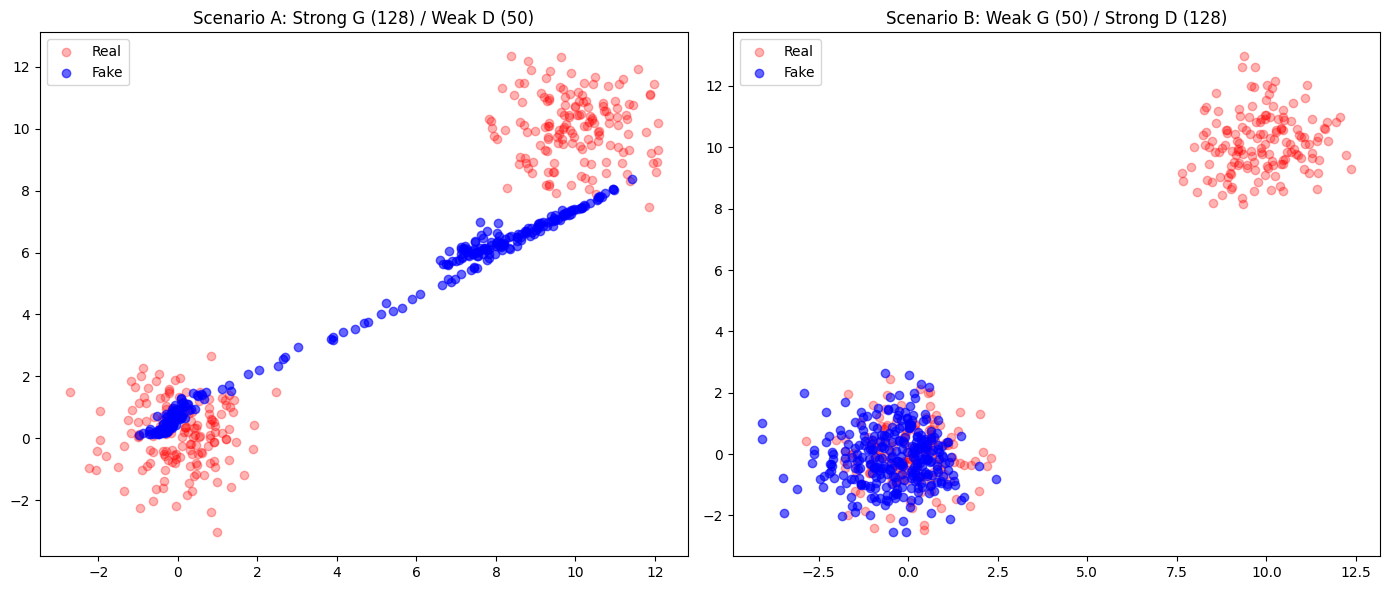

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 1. Define Architecture Variants ---

class Generator(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        # hidden_dim=50 for original, 128 for high-capacity
        self.fc = nn.Sequential(
            nn.Linear(10, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU() if hidden_dim==128 else nn.Identity(),
            nn.Linear(hidden_dim, 2)
        )
    def forward(self, x): return self.fc(x)

class Discriminator(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        # hidden_dim=50 for original, 128 for high-capacity
        self.fc = nn.Sequential(
            nn.Linear(2, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU() if hidden_dim==128 else nn.Identity(),
            nn.Linear(hidden_dim, 1), nn.Sigmoid()
        )
    def forward(self, x): return self.fc(x)

# --- 2. Training Function ---

def train_gan(gen, disc, title, epochs=5000):
    criterion = nn.BCELoss()
    opt_g = optim.Adam(gen.parameters(), lr=0.001)
    opt_d = optim.Adam(disc.parameters(), lr=0.001)
    
    for epoch in range(epochs):
        # Train Discriminator
        opt_d.zero_grad()
        real = generate_real_data(64)
        fake = gen(generate_noise(64)).detach()
        loss_d = criterion(disc(real), torch.ones(64, 1).to(device)) + \
                 criterion(disc(fake), torch.zeros(64, 1).to(device))
        loss_d.backward()
        opt_d.step()

        # Train Generator
        opt_g.zero_grad()
        fake = gen(generate_noise(64))
        loss_g = criterion(disc(fake), torch.ones(64, 1).to(device))
        loss_g.backward()
        opt_g.step()
    
    return gen

# --- 3. Execution of Experiments ---

print("Experiment 1: Powerful Generator vs. Weak Discriminator...")
# High-cap Gen (128) + Low-cap Disc (50)
gen_1 = train_gan(Generator(128).to(device), Discriminator(50).to(device), "G > D")

print("Experiment 2: Weak Generator vs. Powerful Discriminator...")
# Low-cap Gen (50) + High-cap Disc (128)
gen_2 = train_gan(Generator(50).to(device), Discriminator(128).to(device), "D > G")

# --- 4. Visualization ---

plt.figure(figsize=(14, 6))

def plot_result(gen, subplot_idx, title):
    plt.subplot(1, 2, subplot_idx)
    gen.eval()
    with torch.no_grad():
        fake = gen(generate_noise(300)).cpu().numpy()
        real = generate_real_data(300).cpu().numpy()
    plt.scatter(real[:, 0], real[:, 1], c='red', alpha=0.3, label='Real')
    plt.scatter(fake[:, 0], fake[:, 1], c='blue', alpha=0.6, label='Fake')
    plt.title(title)
    plt.legend()

plot_result(gen_1, 1, "Scenario A: Strong G (128) / Weak D (50)")
plot_result(gen_2, 2, "Scenario B: Weak G (50) / Strong D (128)")
plt.tight_layout()
plt.show()

**Scenario A: Strong Generator (128) / Weak Discriminator (50)**

The Generator is upgraded to 128 hidden units with an extra layer, while the Discriminator remains at the original capacity of 50 units.

Analysis of the Results: Increasing Generator capacity without a corresponding increase in Discriminator capacity does not necessarily improve results. The Generator became powerful enough to exploit the Discriminator's "blind spots" rather than learning the actual data distribution. Because the Discriminator is too weak to provide a complex boundary, the Generator easily "wins" by finding simple shortcuts.


**Scenario B: Weak Generator (50) / Strong Discriminator (128)**

The Generator remains at the original capacity of 50 units, while the Discriminator is upgraded to 128 hidden units with an extra layer.

Analysis of the Results: When the Discriminator is significantly more powerful, it becomes too effective at distinguishing real from fake data. The Generator often gets stuck in severe mode collapse, repeatedly attempting to cover only one small region.

### Solutions: Exercise 1 Follow-up Questions

#### 1) Observation of Final Generated Data and Loss Curves
* **High-Capacity Generator / Low-Capacity Discriminator**: The generator has enough capacity to model both data modes, but because the discriminator is weak, it may not provide a sharp enough signal to force the generator to cover both clusters accurately. The loss curves often show the generator "winning" easily, potentially leading to **mode collapse** where it only covers one cluster.
* **Low-Capacity Generator / High-Capacity Discriminator**: The discriminator becomes too powerful for the generator to fool. This often results in a **"vanishing gradient"** problem where the generator’s loss becomes very high and stays flat because it cannot find any way to improve against the expert discriminator. The resulting data plot typically shows poor coverage of the real data distribution.
* **Balanced High-Capacity (Both 128 units)**: The loss curves show intense oscillations as both networks improve together. The final data plot shows the best attempt at covering both clusters, as both agents are matched in their ability to learn the complex multimodal distribution.

#### 2) Best Combination for Covering Both Data Modes
The **balanced high-capacity combination** (where both the Generator and Discriminator have 128-unit hidden layers) produces the best results. This setup allows the generator to capture the complexity of the two distinct clusters (modes) while the discriminator is strong enough to provide the necessary feedback to ensure the generator doesn't just settle for one "easy" cluster.

#### 3) Impact of Imbalanced Power
* **What happens**: When one network is significantly more powerful, the competitive nature of the GAN breaks down.
    * If the **Discriminator is too strong**, the Generator receives no useful gradient information to learn from and essentially gets "stuck".
    * If the **Generator is too strong**, it easily finds a single point that fools the weak Discriminator and stops exploring other parts of the data distribution (**mode collapse**).
* **The "Delicate Balancing Act"**: This relates to the game-theoretic foundation of GANs, where the goal is to reach a **Nash equilibrium**. Training only succeeds if both players are matched; if the competition isn't fair, one side dominates, the minimax game ends prematurely, and the generator never learns to replicate the true diversity of the real data distribution.

### Exercise 2: Implementing the Wasserstein GAN (WGAN)

The Wasserstein GAN (WGAN) addresses the fundamental training instabilities of the Vanilla GAN by replacing the classification-based loss with a metric based on the **Earth Mover's distance**. This modification provides more stable gradients and helps mitigate mode collapse by providing a continuous signal even when distributions are disjoint.

#### 2.1. Mathematical Objective and Constraints 
Unlike the original formulation that uses cross-entropy loss, the WGAN seeks to minimize the Wasserstein-1 distance. This is achieved through the following architectural and game-theoretic changes: 
* **Discriminator (Critic)**: In WGAN, the discriminator $D$ is called a **Critic** because it outputs a scalar score representing "realness" rather than a probability. 
* **Lipschitz Constraint**: The [WGAN paper](https://arxiv.org/abs/1701.07875) showed that the Critic must be $1$-Lipschitz continuous. This means that the Critic must have a maximum gradient, which makes GAN training significantly more stable. 
    * **Providing Information**: A "perfect" traditional discriminator provides nearly zero gradient information when it successfully rejects fake samples. By limiting the gradient (Lipschitz constraint), the Critic is forced to be a "worse" binary classifier but a much better teacher, providing a non-zero gradient even in disjoint regions. 
    * **Visualization**: This is visible in Figure 2 of the [WGAN paper](https://arxiv.org/abs/1701.07875), where a standard discriminator's gradient saturates at nearly zero, while the WGAN critic maintains a non-zero gradient effective for training. 
    * **Weight Clipping**: The WGAN enforces the Lipschitz constraint by clipping the Critic's weights (e.g., to $[-0.01, 0.01]$) after every update.

**Implementation: WGAN with Weight Clipping:**

To implement the WGAN, the following modifications were made to the architecture:

* **Removal of Sigmoid**: The `nn.Sigmoid()` activation was removed from the Critic to allow for unbounded real scores.
* **Wasserstein Objective**: The `nn.BCELoss()` was replaced with the mean difference objective.
* **Optimizer Choice**: Switched from `Adam` to `RMSprop` for improved training stability.

```python
# 1. Critic Architecture - Unbounded scores
class Critic(nn.Module):
    def __init__(self, input_dim=2):
        super(Critic, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 50),
            nn.ReLU(),
            nn.Linear(50, 1) # No Sigmoid for WGAN
        )

    def forward(self, x):
        return self.fc(x)

# 2. Training Loop Logic (WGAN Modification)
# --- Train Critic ---
optimizer_d.zero_grad()
# Critic aims to maximize (mean(D(real)) - mean(D(fake)))
# In PyTorch, we minimize the negative of that value
loss_d = -torch.mean(critic(real_data)) + torch.mean(critic(fake_data))
loss_d.backward()
optimizer_d.step()

# Enforce Lipschitz Constraint via Weight Clipping
for p in Critic.parameters():
    p.data.clamp_(-0.01, 0.01)

# --- Train Generator ---
optimizer_g.zero_grad()
# G aims to maximize mean(D(fake))
loss_g = -torch.mean(critic(fake_data))
loss_g.backward()
optimizer_g.step()
```

Training Wasserstein GAN (WGAN) on cpu...
Epoch [0/10000] | Critic Loss: -0.0298 | Gen Loss: -0.0096
Epoch [1000/10000] | Critic Loss: -0.0230 | Gen Loss: -0.0112
Epoch [2000/10000] | Critic Loss: -0.0169 | Gen Loss: -0.0166
Epoch [3000/10000] | Critic Loss: -0.0088 | Gen Loss: -0.0237
Epoch [4000/10000] | Critic Loss: -0.0019 | Gen Loss: -0.0207
Epoch [5000/10000] | Critic Loss: -0.0014 | Gen Loss: -0.0070
Epoch [6000/10000] | Critic Loss: -0.0013 | Gen Loss: -0.0071
Epoch [7000/10000] | Critic Loss: -0.0014 | Gen Loss: -0.0065
Epoch [8000/10000] | Critic Loss: -0.0014 | Gen Loss: -0.0053
Epoch [9000/10000] | Critic Loss: -0.0013 | Gen Loss: -0.0056


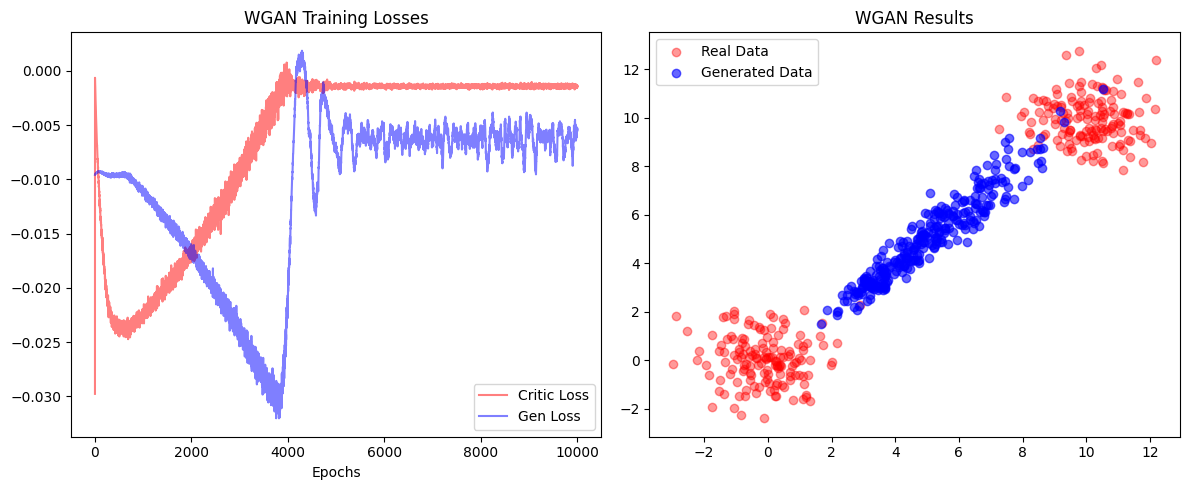

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 1. Define the Models ---

class Generator(nn.Module):
    def __init__(self, input_dim=10, output_dim=2):
        super(Generator, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 50),
            nn.ReLU(),
            nn.Linear(50, 2)
        )

    def forward(self, x):
        return self.fc(x)

# WGAN Modification: The Discriminator is now a "Critic"
class Critic(nn.Module):
    def __init__(self, input_dim=2):
        super(Critic, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 50),
            nn.ReLU(),
            nn.Linear(50, 1) 
            # Note: nn.Sigmoid() removed for WGAN to allow unbounded real scores
        )

    def forward(self, x):
        return self.fc(x)

# --- 2. Utility Functions ---

def generate_real_data(batch_size=64, mean1=0.0, mean2=10.0, std=1.0):
    half_batch = batch_size // 2
    data1 = np.random.normal(mean1, std, (half_batch, 2))
    data2 = np.random.normal(mean2, std, (batch_size - half_batch, 2))
    combined_data = np.vstack([data1, data2])
    return torch.tensor(combined_data, dtype=torch.float32).to(device)

def generate_noise(batch_size=64, noise_dim=10):
    return torch.randn(batch_size, noise_dim).to(device)

# --- 3. Initialization ---

noise_dim = 10
generator = Generator(input_dim=noise_dim).to(device)
critic = Critic().to(device)

# WGAN Modification: Use RMSprop instead of Adam for improved stability
optimizer_g = optim.RMSprop(generator.parameters(), lr=0.00005)
optimizer_d = optim.RMSprop(critic.parameters(), lr=0.00005)

# Training parameters
num_epochs = 10000
batch_size = 64
losses_d = []
losses_g = []

# --- 4. Training Loop ---

print(f"Training Wasserstein GAN (WGAN) on {device}...")

for epoch in range(num_epochs):
    # --- Step A: Train Critic (Discriminator) ---
    optimizer_d.zero_grad()
    
    real_data = generate_real_data(batch_size)
    noise = generate_noise(batch_size, noise_dim)
    fake_data = generator(noise).detach() 
    
    # WGAN Loss: -torch.mean(D(real)) + torch.mean(D(fake))
    # This maximizes the difference between the scores of real and fake data
    loss_d = -torch.mean(critic(real_data)) + torch.mean(critic(fake_data))
    
    loss_d.backward()
    optimizer_d.step()
    
    # WGAN Modification: Weight Clipping to enforce the Lipschitz constraint
    for p in critic.parameters():
        p.data.clamp_(-0.01, 0.01)
    
    # --- Step B: Train Generator ---
    optimizer_g.zero_grad()
    
    noise = generate_noise(batch_size, noise_dim)
    fake_data = generator(noise)
    
    # G wants to maximize the Critic's score for fake data: -torch.mean(D(fake))
    loss_g = -torch.mean(critic(fake_data))
    
    loss_g.backward()
    optimizer_g.step()
    
    # Save statistics
    losses_d.append(loss_d.item())
    losses_g.append(loss_g.item())

    if epoch % 1000 == 0:
        print(f"Epoch [{epoch}/{num_epochs}] | Critic Loss: {loss_d.item():.4f} | Gen Loss: {loss_g.item():.4f}")

# --- 5. Visualization ---

plt.figure(figsize=(12, 5))

# Plot Losses
plt.subplot(1, 2, 1)
plt.plot(losses_d, label='Critic Loss', color='red', alpha=0.5)
plt.plot(losses_g, label='Gen Loss', color='blue', alpha=0.5)
plt.title("WGAN Training Losses")
plt.xlabel("Epochs")
plt.legend()

# Plot Results
plt.subplot(1, 2, 2)
generator.eval()
with torch.no_grad():
    test_noise = generate_noise(300, noise_dim)
    generated = generator(test_noise).cpu().numpy()
    real = generate_real_data(300).cpu().numpy()

plt.scatter(real[:, 0], real[:, 1], c='red', label='Real Data', alpha=0.4)
plt.scatter(generated[:, 0], generated[:, 1], c='blue', label='Generated Data', alpha=0.6)
plt.title("WGAN Results")
plt.legend()
plt.tight_layout()
plt.show()

The distinct behaviors of the Vanilla GAN and Wasserstein GAN Convergence originate from the objectives of their respective loss functions. In Exercise 1, the Vanilla GAN minimizes the [Jensen-Shannon Divergence](https://en.wikipedia.org/wiki/Jensen%E2%80%93Shannon_divergence). When the generated data falls in the 'dead zone' (disjoint distributions), gradients vanish because the JSD creates a constant loss with no directional signal. To ensure some signal, the generator often collapses onto a single cluster (Mode Collapse) rather than traversing the gap. In contrast, the WGAN in Exercise 2 optimizes the Wasserstein (Earth Mover's) distance, a geometric metric that measures the physical cost of transporting mass to the target locations. Because this loss is proportional to distance rather than binary correctness, the model is not strictly punished for occupying the empty space; instead, it minimizes the total transport cost by forming a "bridge"  across the gap, effectively averaging the two clusters rather than committing to just one.

## Solutions for Tutorial 3.2: Evading ML-based IDS

### Exercise 1: Attack Success vs. Perturbation Strength
The goal of this exercise is to adjust the **Perturbation Penalty ($\lambda_{pert}$)** and the generator's learning rate to observe how the modifications affect the ability to evade the target IDS. This hyperparameter defines the critical trade-off between the effectiveness of the attack and its subtlety. 

#### Implementation: AdvGAN Tuning 
We modified the training process to observe how the **$\mathcal{L}_{pert}$** component influences the final detection rate of the victim IDS. This loss penalizes the perturbation size, ensuring that the adversarial changes remain small and subtle.

* **High-Stealth Configuration ($\lambda_{pert}=10.0$):** In this scenario, the generator is strictly penalized for making large changes. The objective is to keep the adversarial traffic as close as possible to the original malicious distribution to avoid detection by both the IDS and any potential secondary realism checks.

* **Aggressive Configuration ($\lambda_{pert}=0.01$):** In this scenario, the penalty is significantly reduced, allowing the generator to apply larger perturbations. This gives the model more freedom to reach the target IDS's "blind spots" and achieve a higher rate of evasion. 

In [5]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# --- 1. CONFIGURATION & DATA LOADING ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_DIR = "./cicids2017"
data_files = [
    'Benign-Monday-no-metadata.parquet', 'Bruteforce-Tuesday-no-metadata.parquet',
    'Portscan-Friday-no-metadata.parquet', 'WebAttacks-Thursday-no-metadata.parquet',
    'DoS-Wednesday-no-metadata.parquet', 'DDoS-Friday-no-metadata.parquet',
    'Infiltration-Thursday-no-metadata.parquet', 'Botnet-Friday-no-metadata.parquet'
]

# Merge and Clean
df_list = [pd.read_parquet(os.path.join(DATA_DIR, f)) for f in data_files]
df_data = pd.concat(df_list, axis=0, ignore_index=True).drop_duplicates()
df_numeric = df_data.select_dtypes(include=[np.number]).replace([np.inf, -np.inf], np.nan).dropna()

X = df_numeric.drop(columns='Label', errors='ignore')
y = df_data.loc[df_numeric.index, "Label"].map({'Benign': 0}).fillna(1).astype(int)

# Scale and Split
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
input_dim = X_train.shape[1]

# --- 2. VICTIM IDS MODEL (KDDNet) ---
class KDDNet(nn.Module):
    def __init__(self, input_dim):
        super(KDDNet, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128), nn.Tanh(), nn.Dropout(0.3),
            nn.Linear(128, 64), nn.Tanh(), nn.Dropout(0.3),
            nn.Linear(64, 1), nn.Sigmoid()
        )
    def forward(self, x): return self.model(x)

target_ids_pytorch = KDDNet(input_dim).to(device)
train_loader = DataLoader(TensorDataset(torch.tensor(X_train, dtype=torch.float32), 
                                        torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)), 
                          batch_size=512, shuffle=True)

# Quick training of the victim
target_opt = optim.Adam(target_ids_pytorch.parameters(), lr=0.001)
criterion_bce = nn.BCELoss()
target_ids_pytorch.train()
for _ in range(3):
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        target_opt.zero_grad()
        criterion_bce(target_ids_pytorch(X_b), y_b).backward()
        target_opt.step()

# --- 3. ADVGAN ARCHITECTURE ---
class AdvGAN_Generator(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.model = nn.Sequential(nn.Linear(input_dim, 128), nn.ReLU(), nn.Linear(128, 128), nn.ReLU(),
                                   nn.Linear(128, input_dim), nn.Tanh())
    def forward(self, x, mask):
        return x + (self.model(x) * 0.1) * mask

class AdvGAN_Discriminator(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.model = nn.Sequential(nn.Linear(input_dim, 128), nn.ReLU(), nn.Linear(128, 1), nn.Sigmoid())
    def forward(self, x): return self.model(x)

# Setup Masks
feature_names = X.columns.tolist()
immutable_features = ['Protocol', 'Fwd PSH Flags', 'FIN Flag Count', 'SYN Flag Count']
mask = np.ones(len(feature_names))
immutable_indices = [feature_names.index(f) for f in immutable_features if f in feature_names]
mask[immutable_indices] = 0
mask_tensor = torch.tensor(mask, dtype=torch.float32, device=device)

# --- 4. EXERCISE 1: TRAINING FUNCTION WITH RETURN ---
def train_advgan_tuned(lambda_pert_val, lr_g):
    print(f"\n🚀 Training AdvGAN: lambda_pert={lambda_pert_val}, lr_g={lr_g}")
    gen_model = AdvGAN_Generator(input_dim).to(device)
    disc_model = AdvGAN_Discriminator(input_dim).to(device)
    opt_g = optim.Adam(gen_model.parameters(), lr=lr_g)
    opt_d = optim.Adam(disc_model.parameters(), lr=0.001)
    loss_mse = nn.MSELoss()
    
    mal_l = DataLoader(TensorDataset(torch.tensor(X_train[y_train == 1], dtype=torch.float32)), batch_size=512, shuffle=True)
    ben_l = DataLoader(TensorDataset(torch.tensor(X_train[y_train == 0], dtype=torch.float32)), batch_size=512, shuffle=True)

    for epoch in range(3):
        for (mal_b,), (ben_b,) in zip(mal_l, ben_l):
            mal_b, ben_b = mal_b.to(device), ben_b.to(device)
            # Disc update
            opt_d.zero_grad()
            d_loss = (criterion_bce(disc_model(ben_b), torch.ones(ben_b.size(0), 1).to(device)) + 
                      criterion_bce(disc_model(gen_model(mal_b, mask_tensor).detach()), torch.zeros(mal_b.size(0), 1).to(device))) / 2
            d_loss.backward(); opt_d.step()
            # Gen update
            opt_g.zero_grad()
            adv_g = gen_model(mal_b, mask_tensor)
            g_loss = criterion_bce(disc_model(adv_g), torch.ones(mal_b.size(0), 1).to(device)) + \
                     1.0 * criterion_bce(target_ids_pytorch(adv_g), torch.zeros(mal_b.size(0), 1).to(device)) + \
                     lambda_pert_val * loss_mse(adv_g, mal_b)
            g_loss.backward(); opt_g.step()

    # Evaluation
    gen_model.eval()
    X_test_mal_t = torch.tensor(X_test[y_test == 1], dtype=torch.float32).to(device)
    with torch.no_grad():
        preds = (target_ids_pytorch(gen_model(X_test_mal_t, mask_tensor)).squeeze() > 0.5)
        print(f"✅ Final Detection Rate: {preds.float().mean().item():.2%}")
    
    return gen_model  # CRITICAL: Return the model to avoid TypeError

# Execute Exercise 1
train_advgan_tuned(lambda_pert_val=10.0, lr_g=0.001)
train_advgan_tuned(lambda_pert_val=0.01, lr_g=0.001)




🚀 Training AdvGAN: lambda_pert=10.0, lr_g=0.001
✅ Final Detection Rate: 73.86%

🚀 Training AdvGAN: lambda_pert=0.01, lr_g=0.001
✅ Final Detection Rate: 62.94%


AdvGAN_Generator(
  (model): Sequential(
    (0): Linear(in_features=77, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=77, bias=True)
    (5): Tanh()
  )
)

**Analysis of the Results:**
Based on the execution output, we observe a clear correlation between perturbation strength and evasion success: 
* **Observation of Results**: With $\lambda_{pert}=10.0$ (High Stealth), the final detection rate was higher than when the penalty was lowered to $0.01$ (Aggressive). 
* **Evasion Effectiveness**: The results confirm that reducing the perturbation penalty allows the generator to craft more effective adversarial samples. The lower detection rate in the aggressive configuration indicates that larger modifications allow the traffic to move further away from the malicious cluster learned by the IDS. 

### Exercise 2: Compare Models

In [6]:
# --- 5. EXECUTION ---
# Execute Exercise 1
generator = train_advgan_tuned(lambda_pert_val=0.01, lr_g=0.001)

# --- 6. EXERCISE 2: TRANSFERABILITY ---
print("\n🌲 Training Random Forest as Alternative IDS...")
rf_ids = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf_ids.fit(X_train, y_train)

with torch.no_grad():
    X_test_mal_t = torch.tensor(X_test[y_test == 1], dtype=torch.float32).to(device)
    adv_test_samples = generator(X_test_mal_t, mask_tensor).cpu().numpy()

rf_adv_det_rate = accuracy_score(y_test[y_test == 1], rf_ids.predict(adv_test_samples))
print(f"📊 RF Detection Rate on Transferred Attacks: {rf_adv_det_rate:.2%}")


🚀 Training AdvGAN: lambda_pert=0.01, lr_g=0.001
✅ Final Detection Rate: 76.87%

🌲 Training Random Forest as Alternative IDS...
📊 RF Detection Rate on Transferred Attacks: 0.00%


---

[![Star our repository](https://img.shields.io/static/v1.svg?logo=star&label=⭐&message=Star%20Our%20Repository&color=yellow)](https://github.com/clandolt/mlcysec_notebooks/)  If you found this tutorial helpful, please **⭐ star our repository** to show your support.   
[![Ask questions](https://img.shields.io/static/v1.svg?logo=star&label=❔&message=Ask%20Questions&color=9cf)](https://github.com/clandolt/mlcysec_notebooks/issues)  For any **questions**, **typos**, or **bugs**, kindly open an issue on GitHub — we appreciate your feedback!

---